In [27]:
print("=" * 50)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 50)

for ticker in TICKERS:
    df = labeled_data[ticker]
    counts = df["label"].value_counts().sort_index()
    total = len(df)
    print(f"\n{ticker}")
    print(f"  Total days     : {total}")
    print(f"  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic")
    print(f"  Oversold  (0)  : {counts.get(0,0):>4} ({counts.get(0,0)/total*100:.1f}%)")
    print(f"  Neutral   (1)  : {counts.get(1,0):>4} ({counts.get(1,0)/total*100:.1f}%)")
    print(f"  Overbought(2)  : {counts.get(2,0):>4} ({counts.get(2,0)/total*100:.1f}%)")

print("\n02_features.ipynb complete. Proceeding to 03_modelling.ipynb")

FEATURE ENGINEERING SUMMARY

RELIANCE.NS
  Total days     : 708
  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic
  Oversold  (0)  :   12 (1.7%)
  Neutral   (1)  :  674 (95.2%)
  Overbought(2)  :   22 (3.1%)

TCS.NS
  Total days     : 708
  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic
  Oversold  (0)  :   20 (2.8%)
  Neutral   (1)  :  675 (95.3%)
  Overbought(2)  :   13 (1.8%)

INFY.NS
  Total days     : 708
  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic
  Oversold  (0)  :   15 (2.1%)
  Neutral   (1)  :  677 (95.6%)
  Overbought(2)  :   16 (2.3%)

HDFCBANK.NS
  Total days     : 708
  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic
  Oversold  (0)  :   19 (2.7%)
  Neutral   (1)  :  662 (93.5%)
  Overbought(2)  :   27 (3.8%)

WIPRO.NS
  Total days     : 708
  Features       : RSI, MACD, Bollinger Bands, ATR, Stochastic
  Oversold  (0)  :   11 (1.6%)
  Neutral   (1)  :  676 (95.5%)
  Overbought(2)  :   21 (3.0%)

02_features.ipynb 

## 8. Summary

In [26]:
for ticker in TICKERS:
    out_path = PROCESSED_DIR / f"{ticker.replace('.', '_')}_features.csv"
    df = labeled_data[ticker].copy()
    
    # Flatten any MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Convert all column names to strings
    df.columns = [str(c) for c in df.columns]
    
    df.to_csv(out_path)
    print(f"Saved: {out_path}")

print("\nAll processed files saved. Ready for modelling.")

Saved: ..\data\processed\RELIANCE_NS_features.csv
Saved: ..\data\processed\TCS_NS_features.csv
Saved: ..\data\processed\INFY_NS_features.csv
Saved: ..\data\processed\HDFCBANK_NS_features.csv
Saved: ..\data\processed\WIPRO_NS_features.csv

All processed files saved. Ready for modelling.


In [ ]:
pip install pyarrow

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.3 MB ? eta -:--:--
   - -------------------------------------- 0.8/27.3 MB 1.9 MB/s eta 0:00:15
   - -------------------------------------- 1.3/27.3 MB 2.4 MB/s eta 0:00:11
   -- ------------------------------------- 1.8/27.3 MB 2.3 MB/s eta 0:00:12
   --- ------------------------------------ 2.1/27.3 MB 2.2 MB/s eta 0:00:12
   --- ------------------------------------ 2.6/27.3 MB 2.0 MB/s eta 0:00:13
   ---- ----------------------------------- 2.9/27.3 MB 2.1 MB/s eta 0:00:12
   ---- ----------------------------------- 3.4/27.3 MB 2.0 MB/s eta 0:00:12
   ----- ---------------------------------- 3.9/27.3 MB 2.1 MB/s eta 0:00:12
   ------ --------------------------------- 4.5/27.3 MB 2.1 MB/s eta 0:00:11
   ------ -----------------

## 7. Save Processed Data

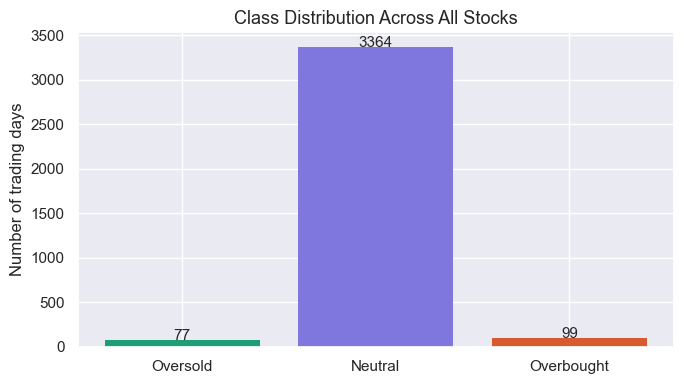


Class balance:
  Oversold    :   77 days (2.2%)
  Neutral     : 3364 days (95.0%)
  Overbought  :   99 days (2.8%)


In [ ]:
all_labels = pd.concat([
    labeled_data[t]["label"] for t in TICKERS
])

counts = all_labels.value_counts().sort_index()
labels = ["Oversold", "Neutral", "Overbought"]
colors = ["#1D9E75", "#7F77DD", "#D85A30"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts.values, color=colors, edgecolor="none")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=11)

plt.title("Class Distribution Across All Stocks", fontsize=13)
plt.ylabel("Number of trading days")
plt.tight_layout()
plt.savefig("../data/processed/06_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClass balance:")
for i, name in enumerate(labels):
    pct = counts.get(i, 0) / len(all_labels) * 100
    print(f"  {name:12s}: {counts.get(i,0):>4} days ({pct:.1f}%)")

## 6. Class Distribution Analysis

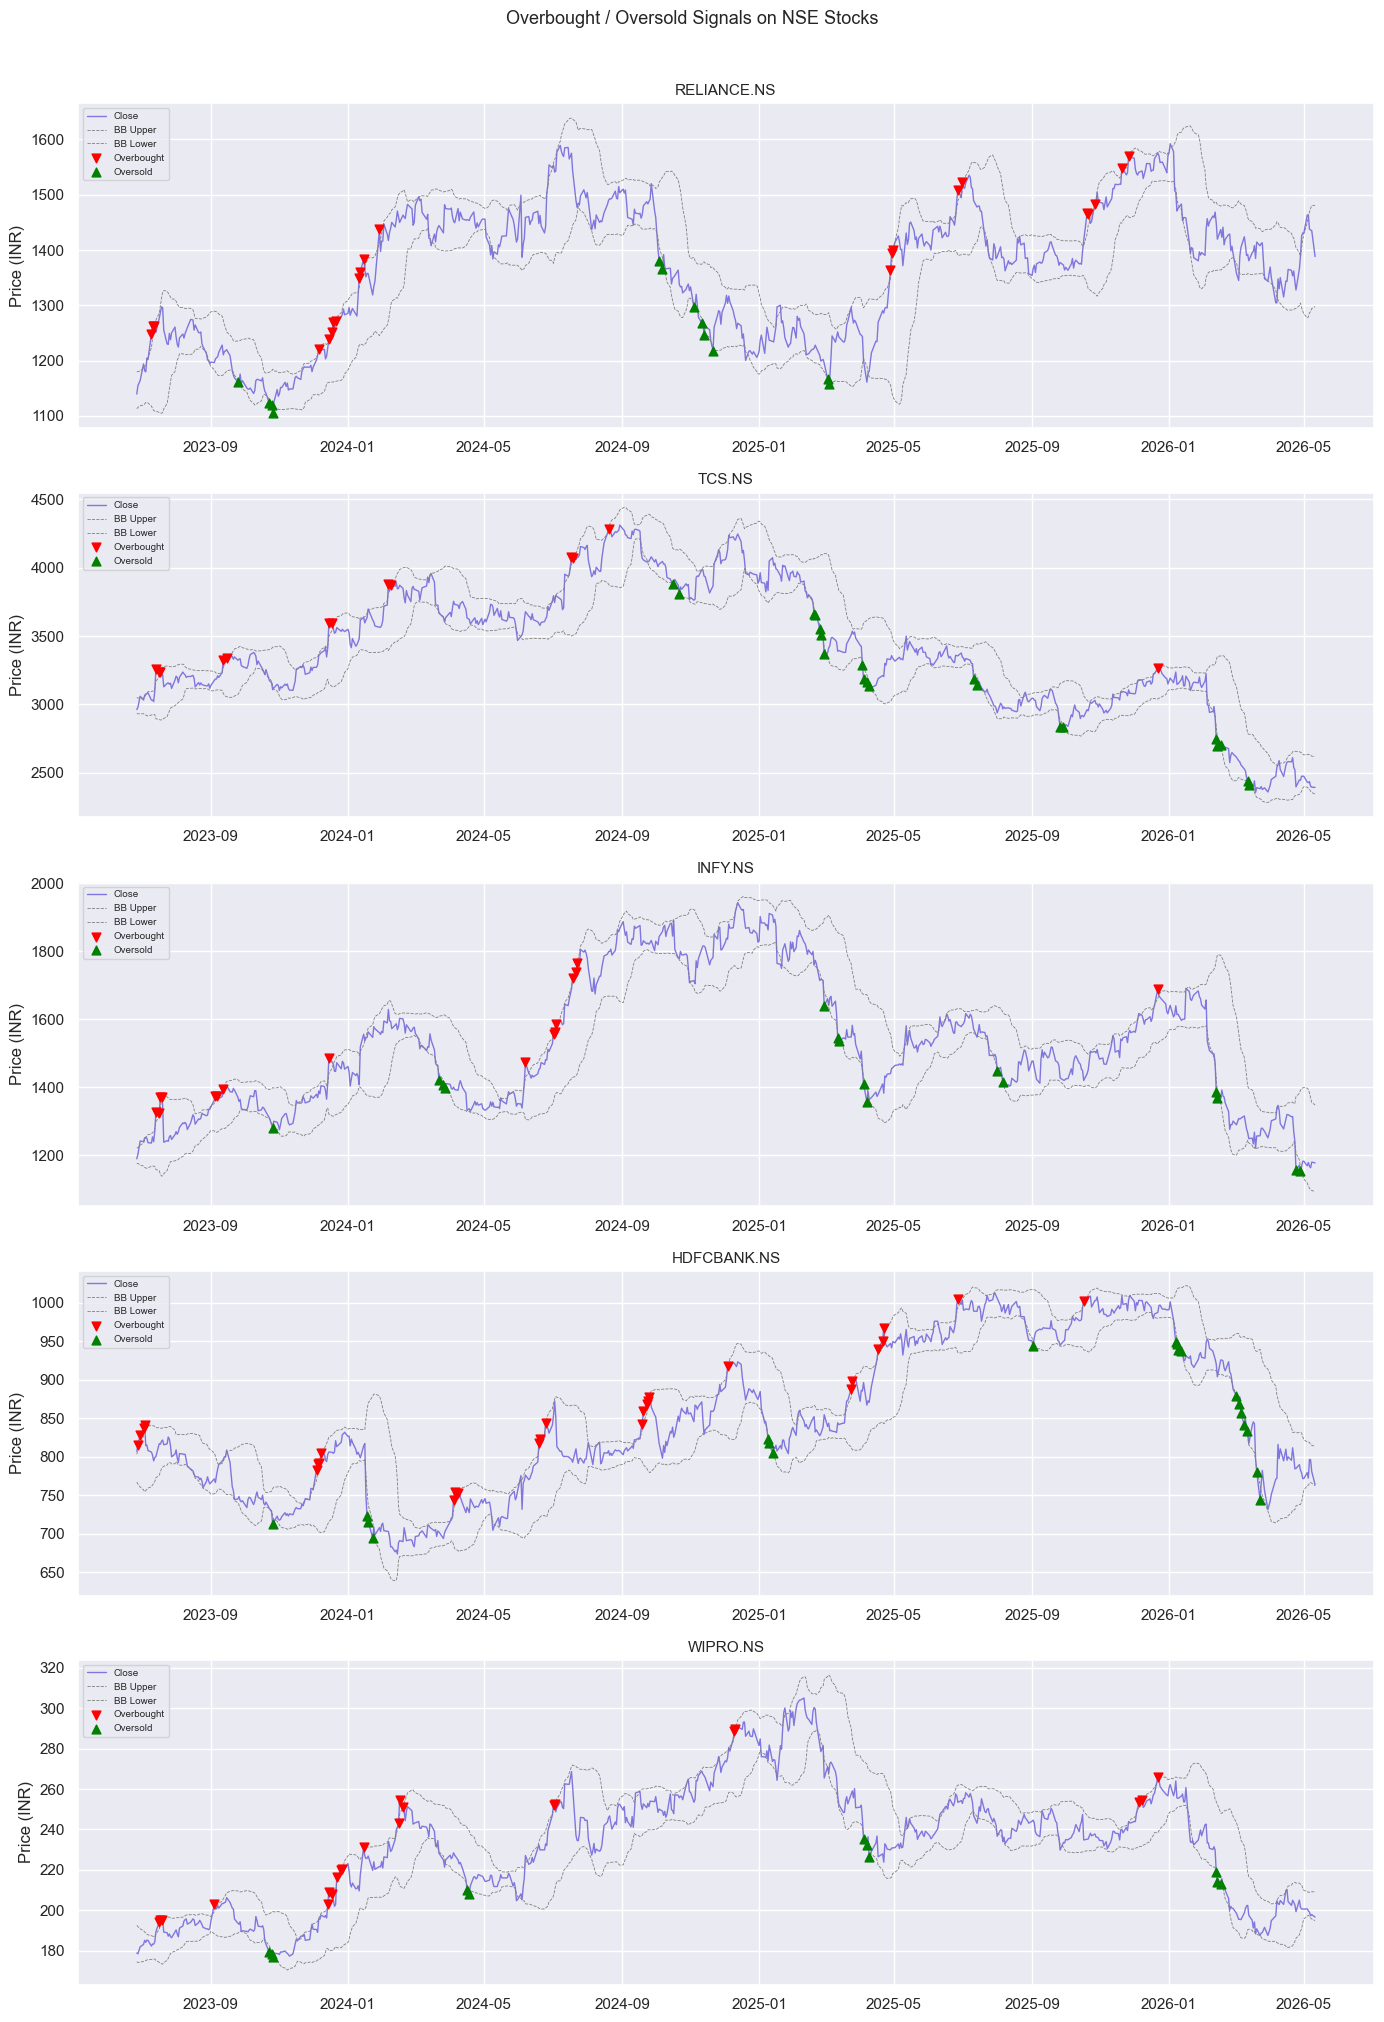

Chart saved.


In [ ]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 20), sharex=False)

for ax, ticker in zip(axes, TICKERS):
    df = labeled_data[ticker].copy()
    
    ax.plot(df.index, df["Close"], color="#7F77DD", linewidth=1, label="Close")
    ax.plot(df.index, df["BB_upper"], color="gray", linewidth=0.6, linestyle="--", label="BB Upper")
    ax.plot(df.index, df["BB_lower"], color="gray", linewidth=0.6, linestyle="--", label="BB Lower")
    
    ob  = df[df["label"] == 2]
    os_ = df[df["label"] == 0]
    
    ax.scatter(ob.index,  ob["Close"],  color="red",   marker="v", s=40, label="Overbought", zorder=5)
    ax.scatter(os_.index, os_["Close"], color="green", marker="^", s=40, label="Oversold",   zorder=5)
    
    ax.set_title(f"{ticker}", fontsize=11)
    ax.set_ylabel("Price (INR)")
    ax.legend(fontsize=7, loc="upper left")

plt.suptitle("Overbought / Oversold Signals on NSE Stocks", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/05_ob_os_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## 5. Visualise Labels on Price Chart

In [ ]:
def generate_labels(df: pd.DataFrame,
                    overbought_rsi: float = 70,
                    oversold_rsi: float = 30) -> pd.DataFrame:
    df = df.copy()
    conditions = [
        (df["RSI_14"] > overbought_rsi) & (df["Close"] > df["BB_upper"]),
        (df["RSI_14"] < oversold_rsi)   & (df["Close"] < df["BB_lower"]),
    ]
    df["label"] = np.select(conditions, [2, 0], default=1)
    return df

labeled_data = {}
for ticker in TICKERS:
    labeled_data[ticker] = generate_labels(indicator_data[ticker])
    counts = labeled_data[ticker]["label"].value_counts().sort_index()
    print(f"\n{ticker}")
    print(f"  Oversold  (0): {counts.get(0, 0):>4} days")
    print(f"  Neutral   (1): {counts.get(1, 0):>4} days")
    print(f"  Overbought(2): {counts.get(2, 0):>4} days")


RELIANCE.NS
  Oversold  (0):   12 days
  Neutral   (1):  674 days
  Overbought(2):   22 days

TCS.NS
  Oversold  (0):   20 days
  Neutral   (1):  675 days
  Overbought(2):   13 days

INFY.NS
  Oversold  (0):   15 days
  Neutral   (1):  677 days
  Overbought(2):   16 days

HDFCBANK.NS
  Oversold  (0):   19 days
  Neutral   (1):  662 days
  Overbought(2):   27 days

WIPRO.NS
  Oversold  (0):   11 days
  Neutral   (1):  676 days
  Overbought(2):   21 days


## 4. Generate Overbought / Oversold Labels
Labels are created using RSI + Bollinger Band conditions:
- **2 = Overbought** — RSI > 70 AND Close > Upper Bollinger Band
- **0 = Oversold** — RSI < 30 AND Close < Lower Bollinger Band  
- **1 = Neutral** — everything else

In [ ]:
sample = indicator_data["RELIANCE.NS"]
print("Columns:", list(sample.columns))
print(f"\nShape: {sample.shape}")
sample.tail(5)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_mid', 'BB_lower', 'ATR_14', 'STOCH_k', 'STOCH_d']

Shape: (708, 15)


Price,Close,High,Low,Open,Volume,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_mid,BB_lower,ATR_14,STOCH_k,STOCH_d
Date,,,,,,,,,,,,,,,
2026-05-05,1463.599976,1473.400024,1450.000000,1460.000000,23543341,66.391578,18.756651,3.862260,14.894391,1462.907267,1370.920013,1278.932759,31.028284,93.965488,95.444748
2026-05-06,1437.900024,1473.300049,1427.500000,1463.000000,14221786,59.708404,19.801296,7.050067,12.751228,1468.697917,1377.585016,1286.472115,32.083410,78.140397,89.785498
2026-05-07,1436.199951,1449.500000,1430.300049,1438.800049,19816903,59.283274,20.258475,9.691749,10.566726,1475.456221,1382.005011,1288.553801,31.163163,77.093554,83.066480
2026-05-08,1435.199951,1442.800049,1417.500000,1426.000000,8663105,59.017091,20.306027,11.814604,8.491422,1480.256914,1387.265009,1294.273104,30.744369,76.477791,77.237248
2026-05-11,1388.199951,1428.000000,1382.000000,1420.000000,15255792,48.088320,16.362586,12.724201,3.638385,1480.589653,1389.165009,1297.740365,32.348340,47.536909,67.036085


## 3. Inspect Indicator Output

In [ ]:
def compute_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # RSI
    df["RSI_14"] = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()
    
    # MACD
    macd = ta.trend.MACD(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()
    df["MACD_hist"] = macd.macd_diff()
    
    # Bollinger Bands
    bb = ta.volatility.BollingerBands(df["Close"], window=20, window_dev=2)
    df["BB_upper"] = bb.bollinger_hband()
    df["BB_mid"]   = bb.bollinger_mavg()
    df["BB_lower"] = bb.bollinger_lband()
    
    # ATR
    df["ATR_14"] = ta.volatility.AverageTrueRange(
        df["High"], df["Low"], df["Close"], window=14
    ).average_true_range()
    
    # Stochastic
    stoch = ta.momentum.StochasticOscillator(
        df["High"], df["Low"], df["Close"], window=14, smooth_window=3
    )
    df["STOCH_k"] = stoch.stoch()
    df["STOCH_d"] = stoch.stoch_signal()
    
    df.dropna(inplace=True)
    return df

# Apply to all tickers
indicator_data = {}
for ticker in TICKERS:
    indicator_data[ticker] = compute_indicators(raw_data[ticker])
    print(f"{ticker:20s} — {indicator_data[ticker].shape[1]} columns after indicators")

RELIANCE.NS          — 15 columns after indicators
TCS.NS               — 15 columns after indicators
INFY.NS              — 15 columns after indicators
HDFCBANK.NS          — 15 columns after indicators
WIPRO.NS             — 15 columns after indicators


## 2. Compute Technical Indicators
We compute 5 core indicators used in overbought/oversold detection:
- **RSI (14)** — momentum oscillator, flags extremes above 70 or below 30
- **MACD** — trend direction and momentum
- **Bollinger Bands (20, 2)** — price envelope, flags breakouts
- **ATR (14)** — volatility measure
- **Stochastic Oscillator** — momentum vs recent high/low range

In [ ]:
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "WIPRO.NS"
]

raw_data = {}

for ticker in TICKERS:
    df = yf.download(ticker, period="3y", auto_adjust=True, progress=False)
    df.columns = df.columns.get_level_values(0)  # flatten MultiIndex
    df.dropna(inplace=True)
    raw_data[ticker] = df
    print(f"{ticker:20s} — {len(df)} rows loaded")

RELIANCE.NS          — 741 rows loaded
TCS.NS               — 741 rows loaded
INFY.NS              — 741 rows loaded
HDFCBANK.NS          — 741 rows loaded
WIPRO.NS             — 741 rows loaded


## 1. Load Stock Data

In [ ]:
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [ ]:
import ta

In [ ]:
pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29497 sha256=776aa4befbdb92e92c671c05aaa865afcc0235faeb878df56a38d0657fd52af0
  Stored in directory: c:\users\shanu\appdata\local\pip\cache\wheels\e3\3a\ee\4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install "numpy==1.26.4"


  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + c:\Users\shanu\stock-analysis-ds\venv\Scripts\python.exe C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\numpy_c8b2ba73e3cd432aa8eab2ed96b30365\vendored-meson\meson\meson.py setup C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\numpy_c8b2ba73e3cd432aa8eab2ed96b30365 C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\numpy_c8b2ba73e3cd432aa8eab2ed96b30365\.mesonpy-e84si6cv -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\numpy_c8b2ba73e3cd432aa8eab2ed96b30365\.mesonpy-e84si6cv\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\numpy_c8b2ba73e3cd432aa8eab2ed96b30365
      Build dir: C:\Users\shanu\AppData\Local\Temp\pip-install-__9v4kkc\num

# 02 — Feature Engineering
## Stock Overbought / Oversold Detection — NSE/BSE
**Goal:** Compute technical indicators (RSI, MACD, Bollinger Bands, ATR, Stochastic)
and generate overbought/oversold labels for model training.